In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
target_columns = [
    "clover_target",
    "dead_target",
    "green_target",
    "gdm_target",
    "total_target",
]

In [6]:
train_df = pd.read_csv("../../output/exp000/preprocessed_train.csv")
oofs_df = pd.read_csv("../../output/exp000/oofs.csv")

print(train_df[target_columns].shape)
print(oofs_df[target_columns].shape)

# モデルの予測値を表示
print(oofs_df.head())

(357, 5)
(357, 5)
   clover_target  dead_target  green_target  gdm_target  total_target
0       3.480326    24.508406     25.925703   27.021128     52.294567
1       4.923923     4.711923     11.123760   16.108263     20.313972
2       4.494537    -0.246012      2.462807    7.315617      6.689571
3       2.310584    23.158194     34.220261   35.657608     58.566658
4       1.495920    12.470833     11.162724   13.817622     26.693539


In [18]:
train_df[target_columns].describe()

,clover_target,dead_target,green_target,gdm_target,total_target
count,357.000000,357.000000,357.000000,357.000000,357.000000
mean,6.649692,12.044548,26.624722,33.274414,45.318097
std,12.117761,12.402007,25.401232,24.935822,27.984015
min,0.000000,0.000000,0.000000,1.040000,1.040000
25%,0.000000,3.200000,8.800000,16.026100,25.271500
50%,1.423500,7.980900,20.800000,27.108200,40.300000
75%,7.242900,17.637800,35.083400,43.675700,57.880000
max,71.786500,83.840700,157.983600,157.983600,185.700000


In [17]:
oofs_df.describe()

,clover_target,dead_target,green_target,gdm_target,total_target
count,357.000000,357.000000,357.000000,357.000000,357.000000
mean,6.274096,12.136401,23.869332,29.707844,41.179818
std,4.364679,6.562374,13.555851,14.698208,16.599095
min,-0.828902,-0.800767,0.333922,3.959808,3.659467
25%,3.074306,6.282688,13.859951,18.266901,28.301168
50%,5.836443,13.405836,21.746756,27.099615,39.339363
75%,8.533640,17.128910,33.862797,40.830444,53.714085
max,21.009241,25.294888,48.554470,56.924782,68.855194


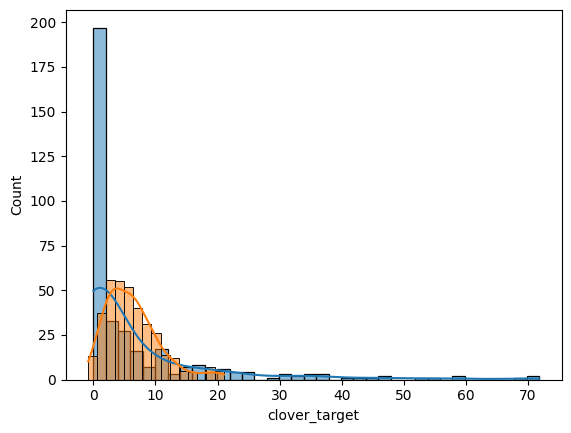

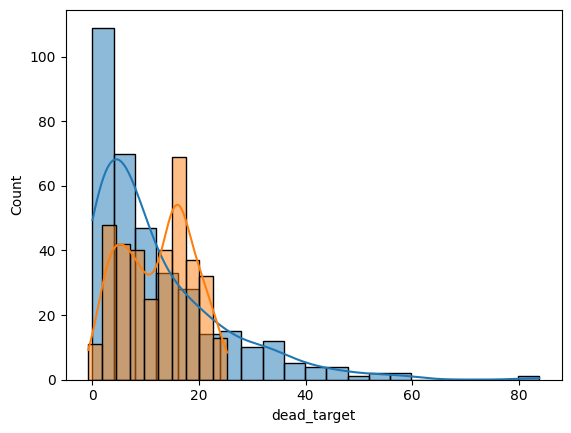

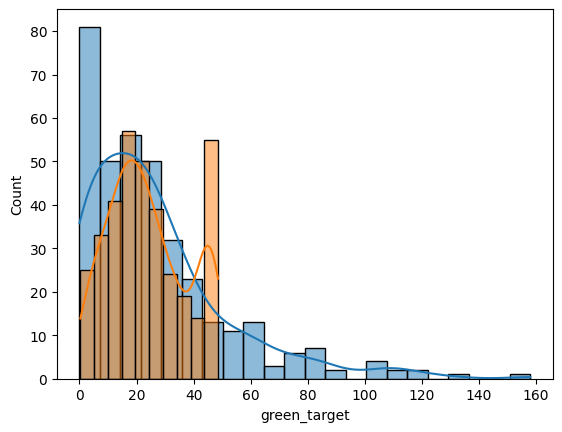

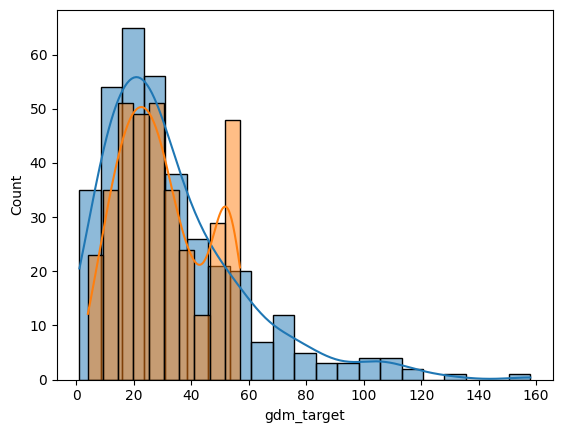

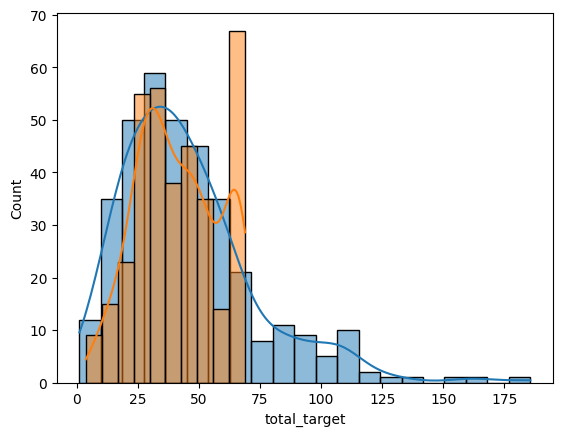

In [8]:
for col in target_columns:
    sns.histplot(data=train_df, x=col, kde=True)
    sns.histplot(data=oofs_df, x=col, kde=True)
    plt.show()

<Axes: xlabel='total_target', ylabel='Count'>

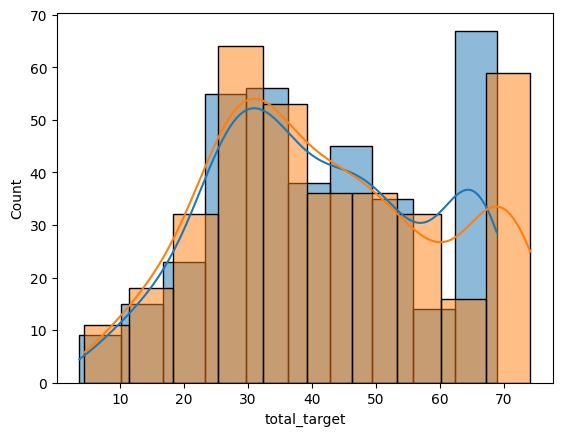

In [23]:
sns.histplot(oofs_df["total_target"], kde=True)
sns.histplot(
    oofs_df[["clover_target", "dead_target", "green_target"]].sum(axis=1), kde=True
)

<Axes: ylabel='Count'>

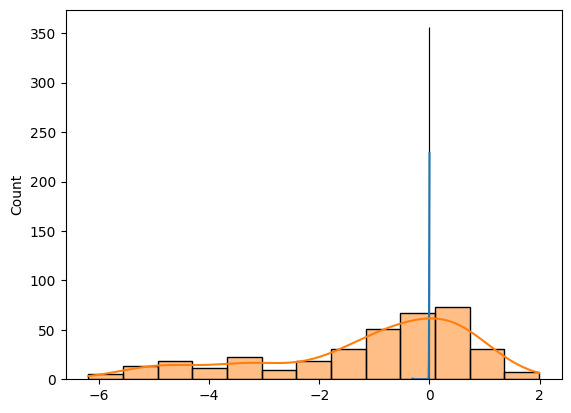

In [19]:
sns.histplot(
    train_df["total_target"]
    - train_df[["clover_target", "dead_target", "green_target"]].sum(axis=1),
    kde=True,
)
sns.histplot(
    oofs_df["total_target"]
    - oofs_df[["clover_target", "dead_target", "green_target"]].sum(axis=1),
    kde=True,
)

In [21]:
(
    train_df["total_target"]
    - train_df[["clover_target", "dead_target", "green_target"]].sum(axis=1)
).value_counts()

 0.000000e+00    254
 7.105427e-15     13
-1.000000e-04     12
-7.105427e-15     10
 1.421085e-14     10
 1.000000e-04     10
 3.552714e-15      7
 1.000000e-04      7
-1.000000e-04      7
-1.421085e-14      6
-1.000000e-04      5
 1.000000e-04      4
-3.552714e-15      3
 1.000000e-04      2
-1.776357e-15      2
 2.842171e-14      1
-3.088000e-01      1
-8.881784e-16      1
-1.000000e-04      1
 1.776357e-15      1
Name: count, dtype: int64

In [25]:
import json

with open("../../output/exp000/results.json", "r") as f:
    results = json.load(f)
results

{'fold_scores': [0.4932094275951385,
  0.6550862431526184,
  0.4260020434856415,
  0.5557386338710785,
  0.4688201725482941],
 'mean_score': 0.5197713041305543,
 'std_score': 0.07962161373358063}

#　所感
- foldごとの精度ばらつきが大きい。なぜ？
- SpicesをGroupKFoldにしてしまうと精度が上がらない
  - StratifiedKFoldにすると安定して向上
  - つまり、種別の汎化性は重要そう
- 画像サイズはそこまで重要じゃないかも？？
  - GroupKFoldで実験してしまっていたので再検討が必要
- `Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g`となるはずが、誤差大きい。差分のほうがいいかも？
  - モデルは`Dry_Clover_g, Dry_Dead_g, Dry_Green_g, GDM_g`の4つだけ予測するでも良さそう。`Dry_Total_g`は合計でLossを出す。
- total_targetの予測結果がサチっている。分布変換必要かも。
- 負の値はclippingしたほうがよい。
- 全体の雰囲気をみたいのでcnnよりtransformer系のほうが良いかも？
- 高速化・TTA・アンサンブル必須。
- 0gでラベルミスがあるとのことなので気をつけたほうがよい
- ドメインシフトがありそう。気をつけたほうがよい。
- Pre_GSHH_NDVI・Height_Ave_cmもAuxLossで使う必要がある。